# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [52]:
#YOUR CODE HERE

import kagglehub
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os


path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")


print("Path to dataset files:", path)
# Проверяем файлы
print("Доступные файлы:")
for file in os.listdir(path):
    print(f"  • {file}")

# Загружаем основной датасет
dc = pd.read_csv(f'{path}/AB_NYC_2019.csv')
df = dc.copy()
print(df.info())
print(f"\\nРазмер: {df.shape}")
print(df.isnull().sum())
df.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data
Доступные файлы:
  • AB_NYC_2019.csv
  • New_York_City_.png
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   pr

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [53]:
#выкиньте ненужные признаки: id, name, host_id, host_name, last_review

#if 'id' and 'Unnamed: 32' in df.columns:
df_clean = df.drop(['id','name','host_id','host_name','last_review'], axis=1)
df_clean['reviews_per_month'] = df['reviews_per_month'].fillna(0)
print(f"Индексы колонок:\n{df_clean.columns.tolist()}")
df_clean.head()

Индексы колонок:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [54]:
print(f"   Уникальных значений: {df_clean['neighbourhood'].nunique()}")
print(f"   Уникальных значений: {df_clean['neighbourhood_group'].nunique()}")

   Уникальных значений: 221
   Уникальных значений: 5


In [55]:
#ONE-HOT ENCODING
print(df_clean['neighbourhood_group'].unique())
df_ohe = pd.get_dummies(df_clean, columns=['neighbourhood_group'], prefix='nbhd', drop_first=True)
#print(df_ohe.columns.tolist())

print(f"\n  ✅ Созданы бинарные колонки,первая в списке будет опущена при drop_first=True:")
ohe_cols = [c for c in df_ohe.columns if c.startswith('nbhd_')]
for col in ohe_cols:
    print(f"    • {col}")


['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']

  ✅ Созданы бинарные колонки,первая в списке будет опущена при drop_first=True:
    • nbhd_Brooklyn
    • nbhd_Manhattan
    • nbhd_Queens
    • nbhd_Staten Island


In [56]:
#  TARGET ENCODING (СРЕДНЯЯ ЦЕНА ПО РАЙОНУ)
target_map = df_ohe.groupby('neighbourhood')['price'].mean()
df_ohe['neighbourhood_encoded'] = df_ohe['neighbourhood'].map(target_map).round()
print(df_ohe[['neighbourhood', 'price', 'neighbourhood_encoded']].head())
print(f"Индексы колонок:\n{df_ohe.columns.tolist()}")

  neighbourhood  price  neighbourhood_encoded
0    Kensington    149                   93.0
1       Midtown    225                  283.0
2        Harlem    150                  119.0
3  Clinton Hill     89                  182.0
4   East Harlem     80                  133.0
Индексы колонок:
['neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'nbhd_Brooklyn', 'nbhd_Manhattan', 'nbhd_Queens', 'nbhd_Staten Island', 'neighbourhood_encoded']


In [57]:
df1 = df_ohe.drop(['neighbourhood'], axis=1)

In [58]:
print(f"Индексы колонок:\n{df1.columns.tolist()}")

Индексы колонок:
['latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'nbhd_Brooklyn', 'nbhd_Manhattan', 'nbhd_Queens', 'nbhd_Staten Island', 'neighbourhood_encoded']


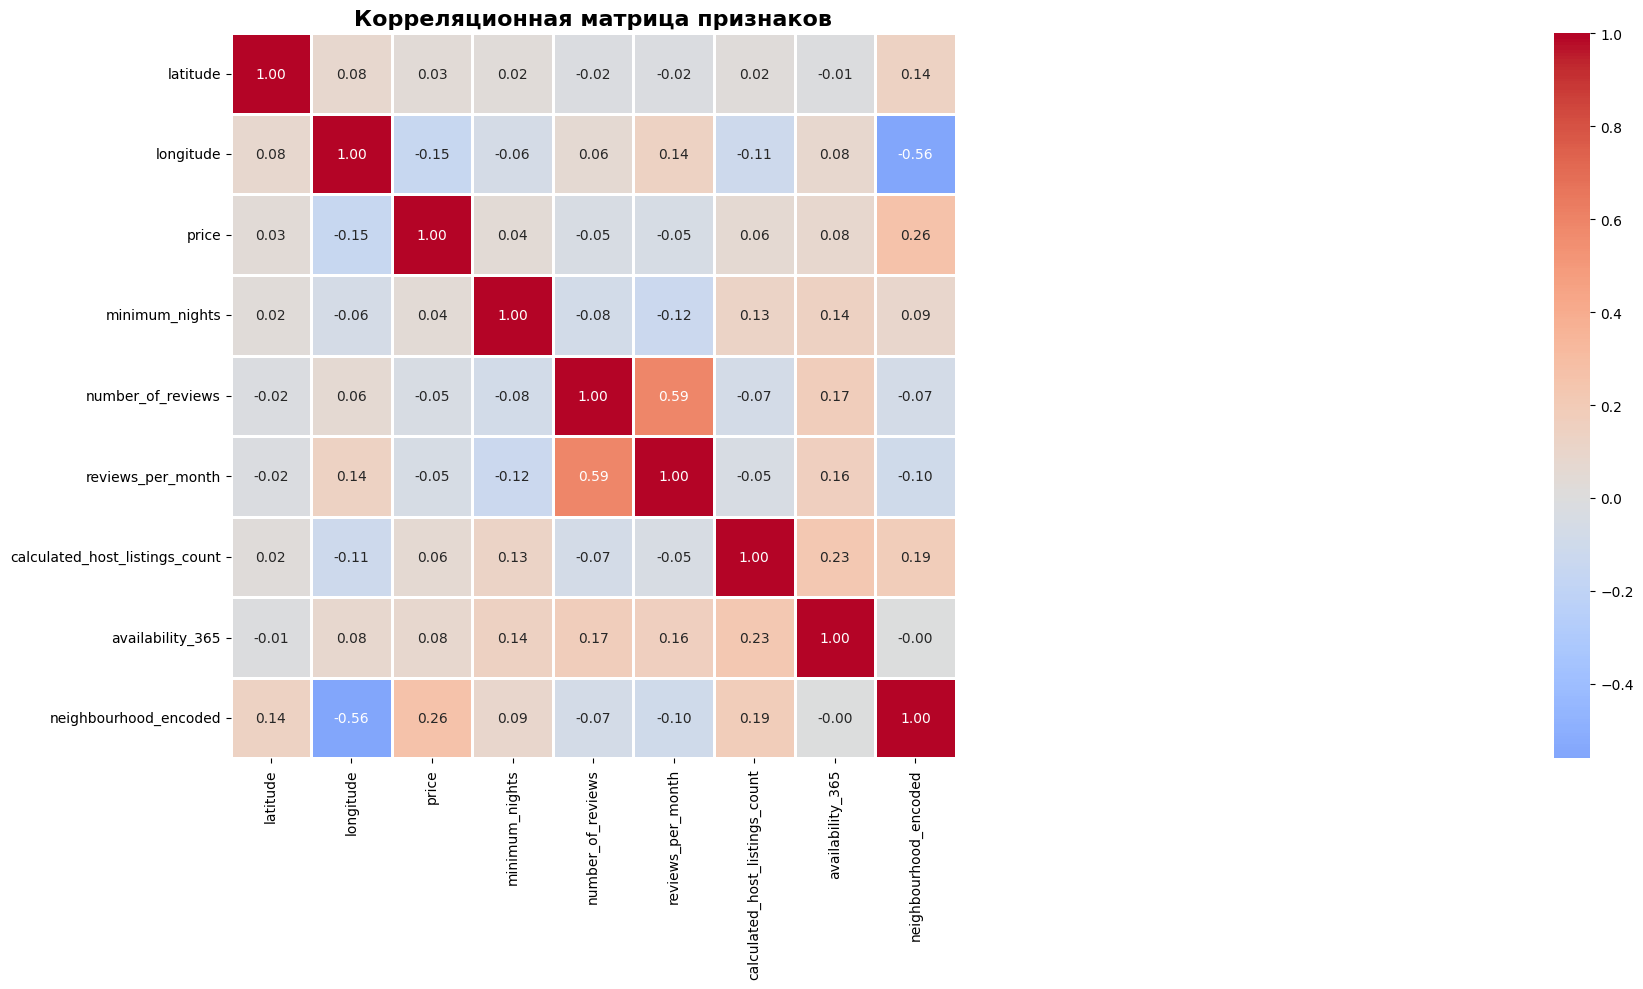

In [59]:
#визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots
df2 = df1.copy()
plt.figure(figsize=(120, 10))
numeric_cols = df2.select_dtypes(include=[np.number]).columns
correlation_matrix = df2[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.9)
plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
#визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots

In [61]:
# перекодируем целевую переменную
data['class'] = data['class'].map({'Normal': 1, 'Abnormal': 0})

#correlation map
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cbar=True, linewidths=.5, fmt= '.2f')
plt.show()


sns.pairplot(data, hue='class');


plt.figure(figsize=(10,6))
sns.boxplot(data=data, x='SalePrice', y='MSZoning', hue='MSZoning')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='OverallQual', y="SalePrice")
plt.show()

NameError: name 'data' is not defined


📈 1. РАСПРЕДЕЛЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
----------------------------------------
   Числовых признаков: 8
   Признаки: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


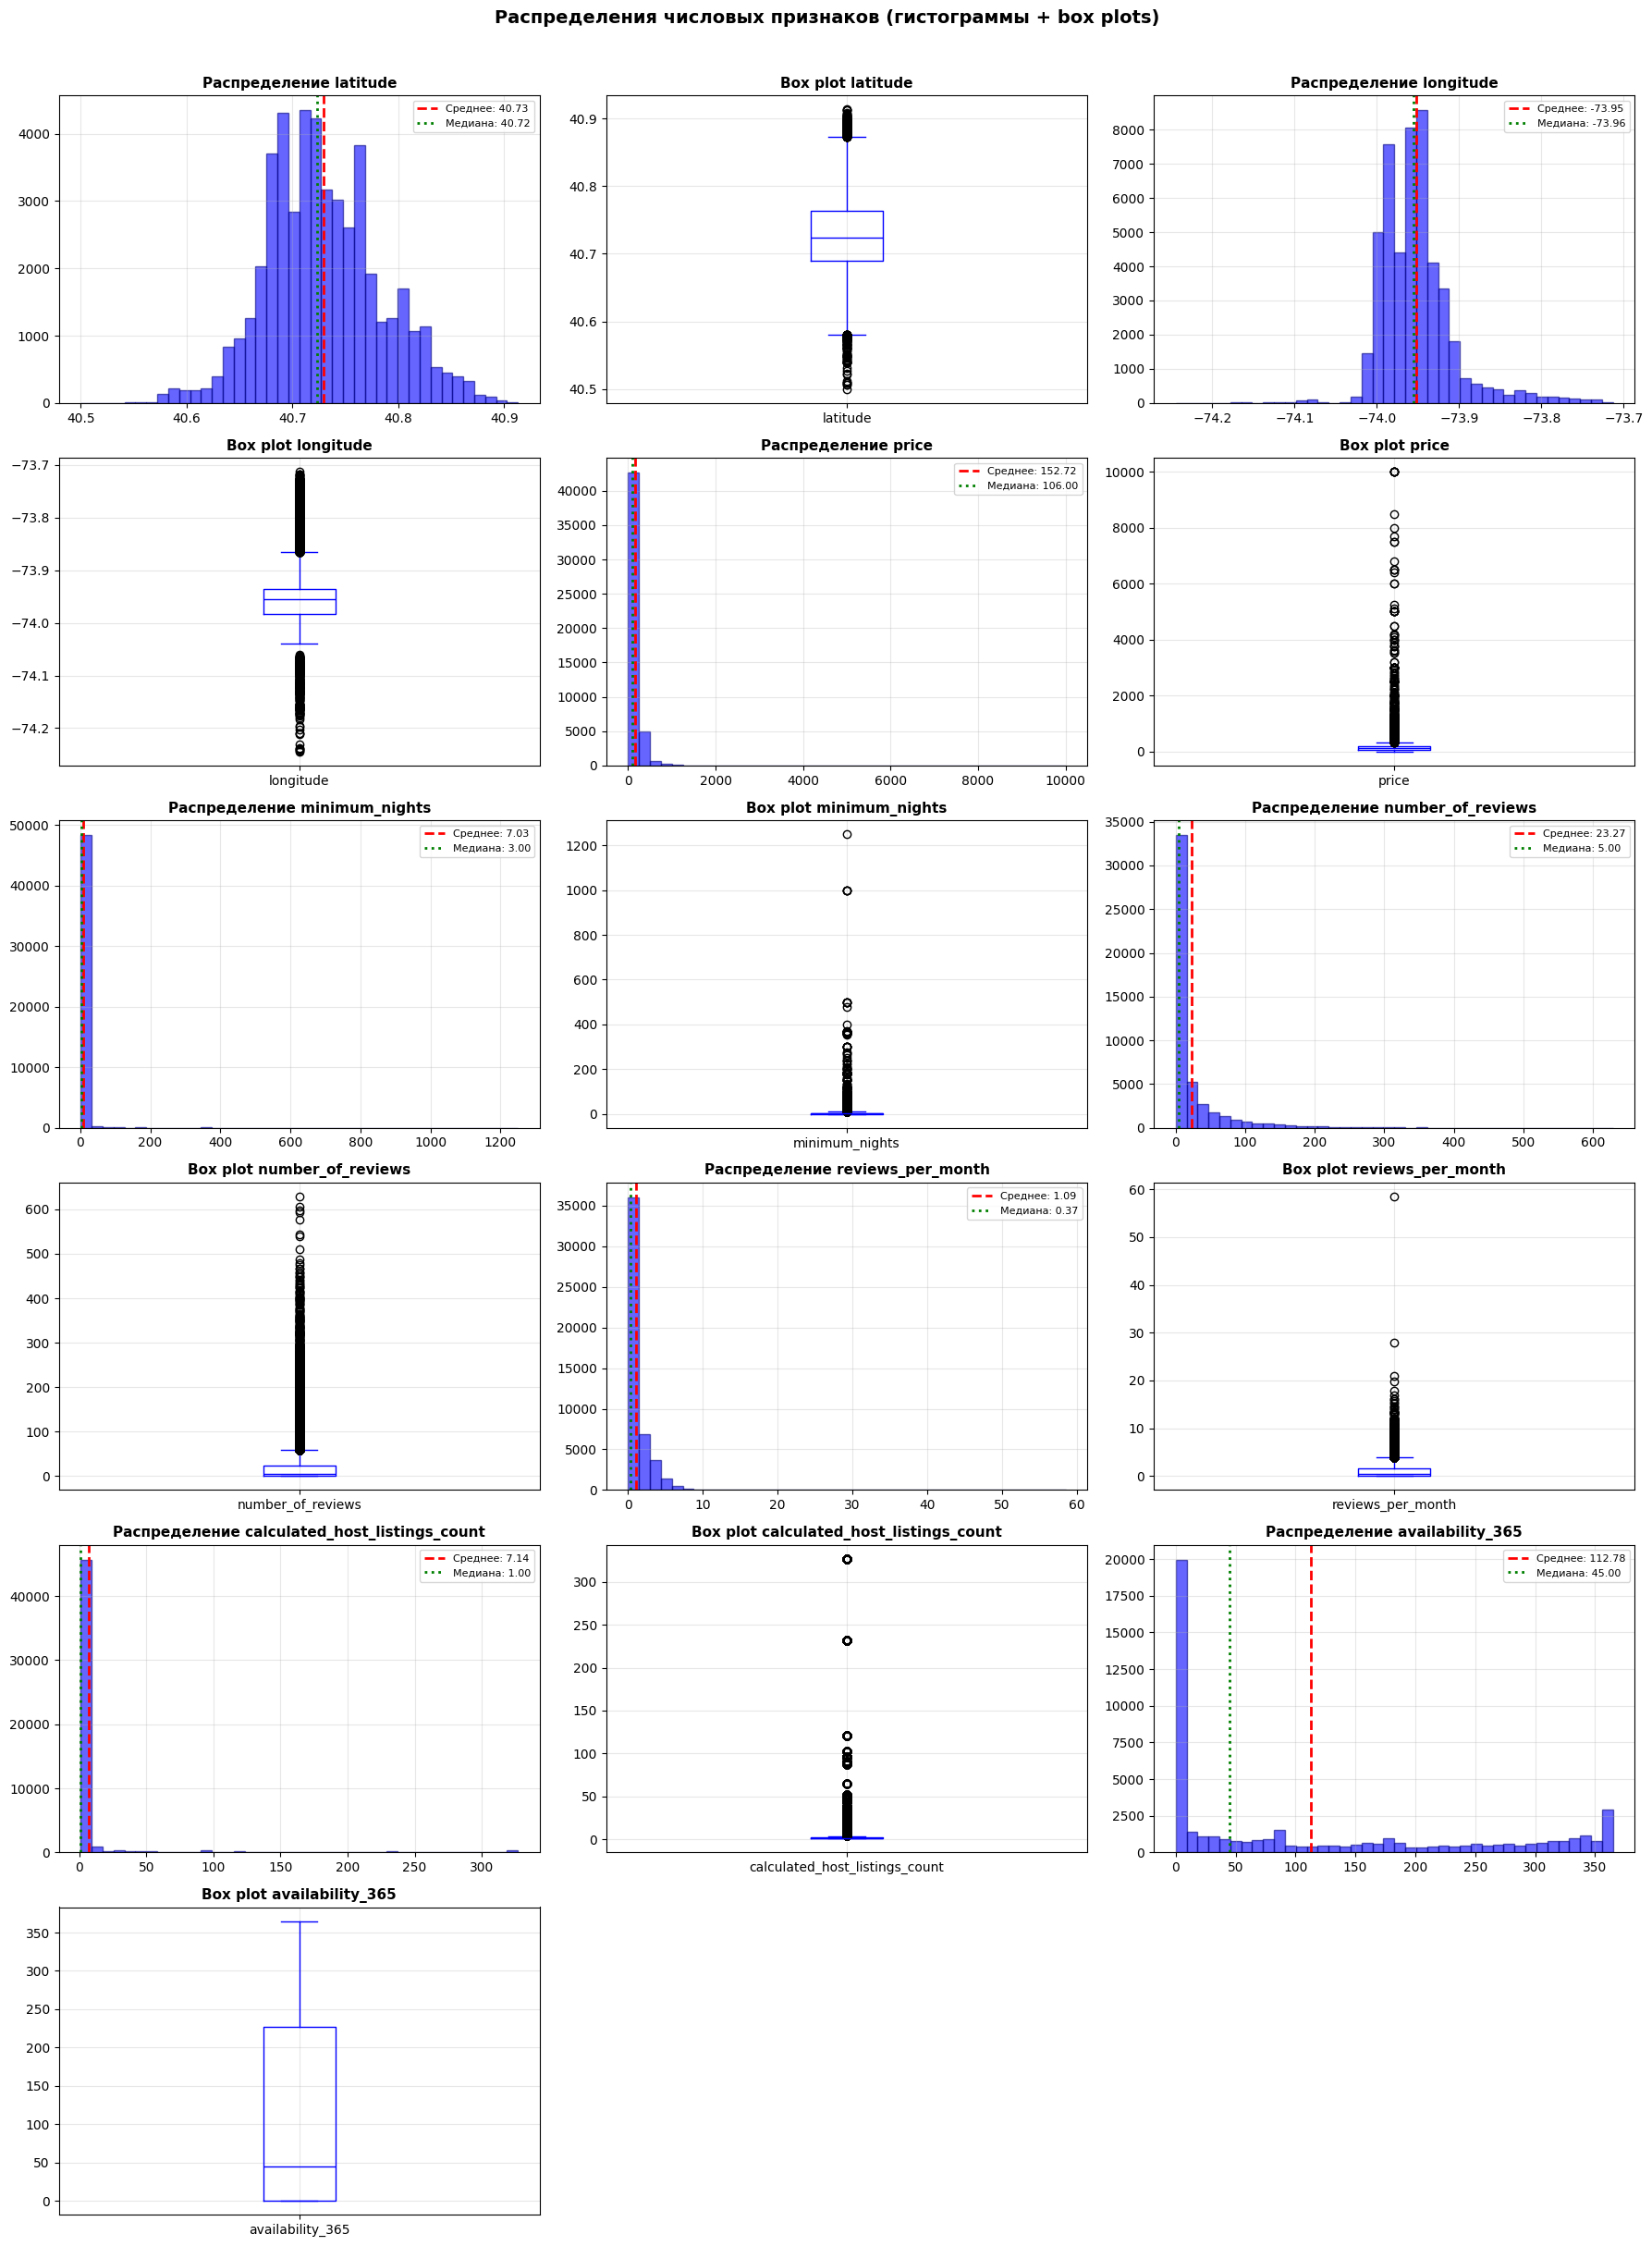


📊 2. СТАТИСТИЧЕСКОЕ ОПИСАНИЕ
----------------------------------------
           latitude     longitude         price  minimum_nights  number_of_reviews  reviews_per_month  calculated_host_listings_count  availability_365
count  48895.000000  48895.000000  48895.000000    48895.000000       48895.000000       48895.000000                    48895.000000      48895.000000
mean      40.728949    -73.952170    152.720687        7.029962          23.274466           1.090910                        7.143982        112.781327
std        0.054530      0.046157    240.154170       20.510550          44.550582           1.597283                       32.952519        131.622289
min       40.499790    -74.244420      0.000000        1.000000           0.000000           0.000000                        1.000000          0.000000
25%       40.690100    -73.983070     69.000000        1.000000           1.000000           0.040000                        1.000000          0.000000
50%       40.7230

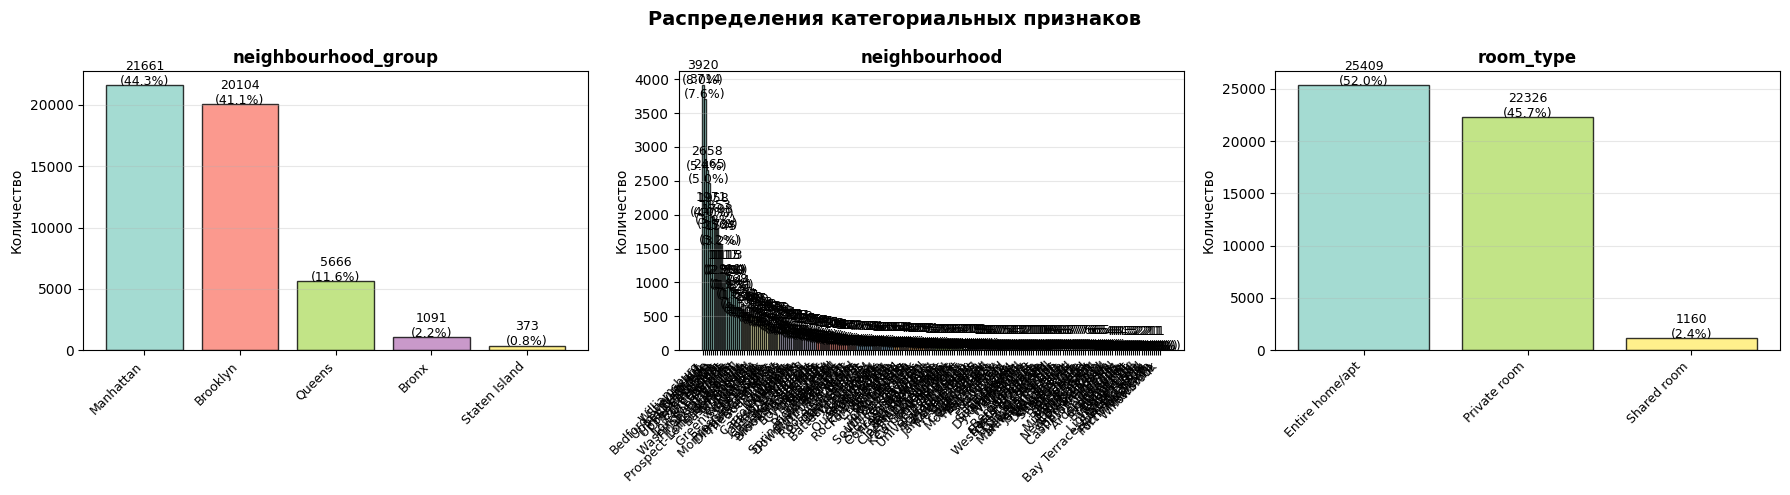


📊 4. МАТРИЦА ПОПАРНЫХ КОРРЕЛЯЦИЙ
----------------------------------------


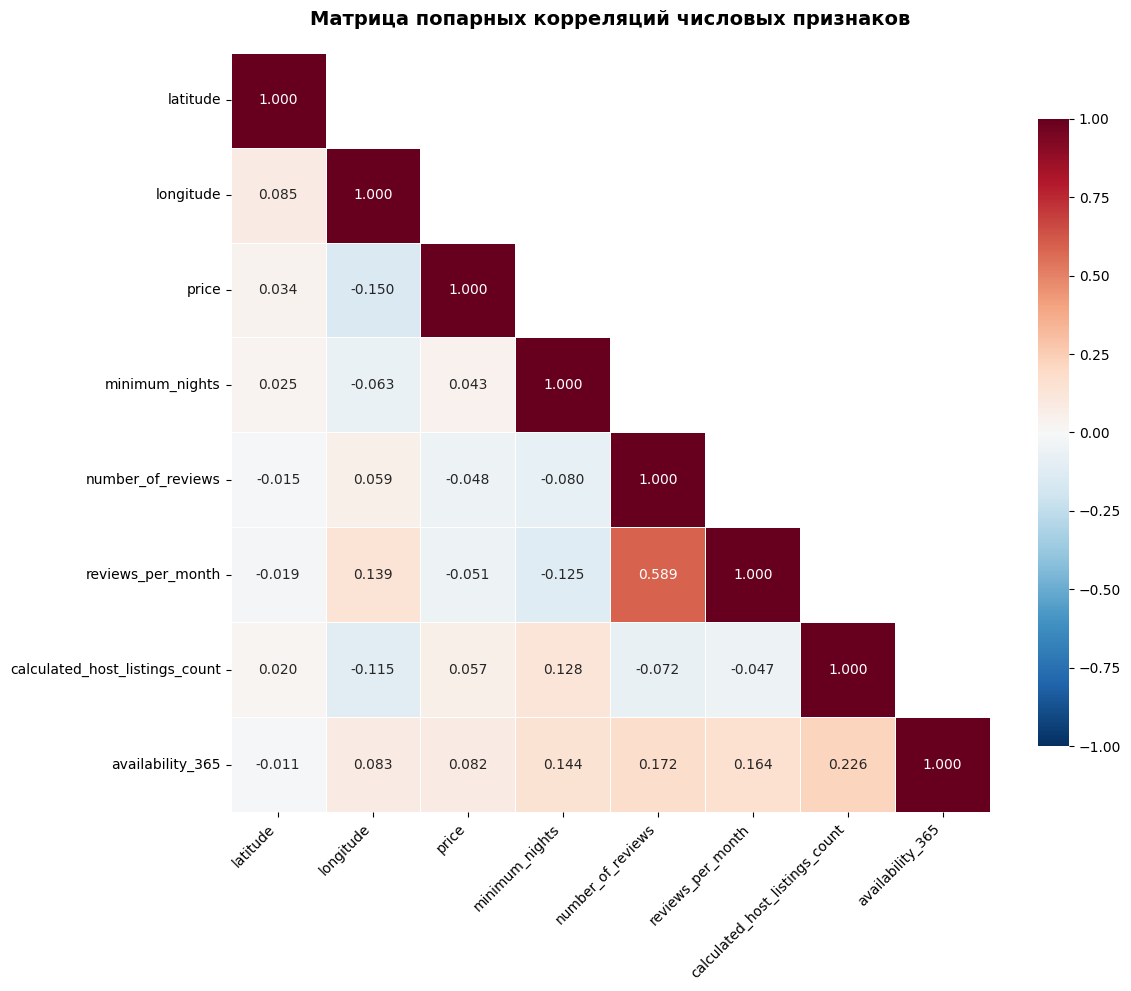


  🔥 Топ-5 самых сильных корреляций:
    number_of_reviews         ↔ reviews_per_month         :  0.5894
    calculated_host_listings_count ↔ availability_365          :  0.2257
    number_of_reviews         ↔ availability_365          :  0.1720
    reviews_per_month         ↔ availability_365          :  0.1637
    longitude                 ↔ price                     : -0.1500

📊 5. PAIR PLOTS
----------------------------------------
   Топ-5 признаков по дисперсии: ['price', 'availability_365', 'number_of_reviews', 'calculated_host_listings_count', 'minimum_nights']
   Строю pairplot для 5 признаков...


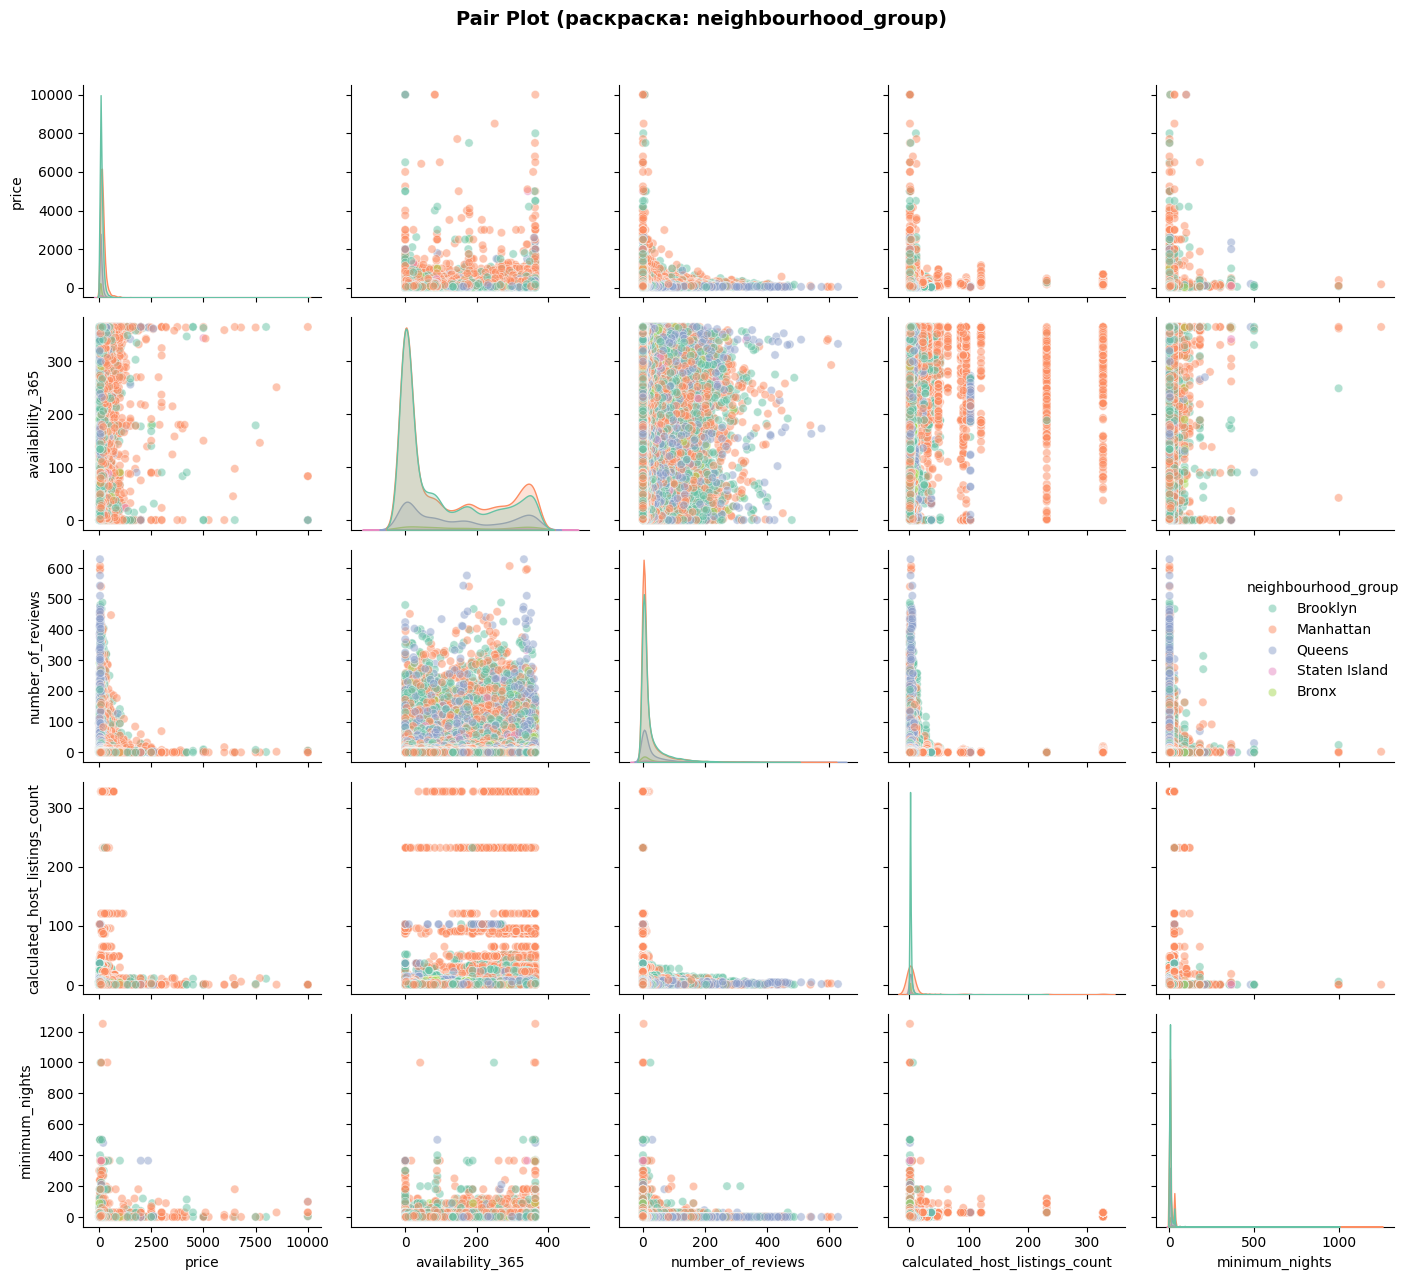


📊 6. РАСПРЕДЕЛЕНИЯ ПО КАТЕГОРИЯМ
----------------------------------------


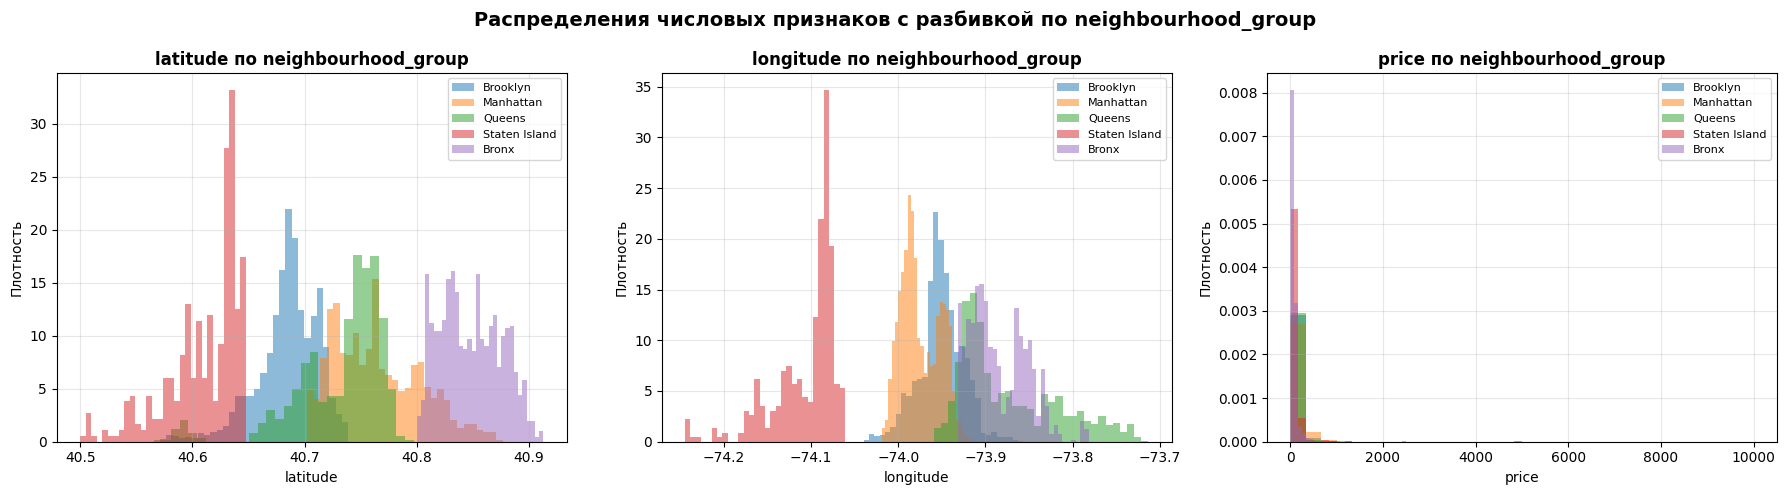


📊 7. BOX PLOTS ПО КАТЕГОРИЯМ
----------------------------------------


/tmp/ipykernel_2822/817033192.py:254: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=main_cat, y=key_num, data=df, ax=axes[1], palette='Set2')


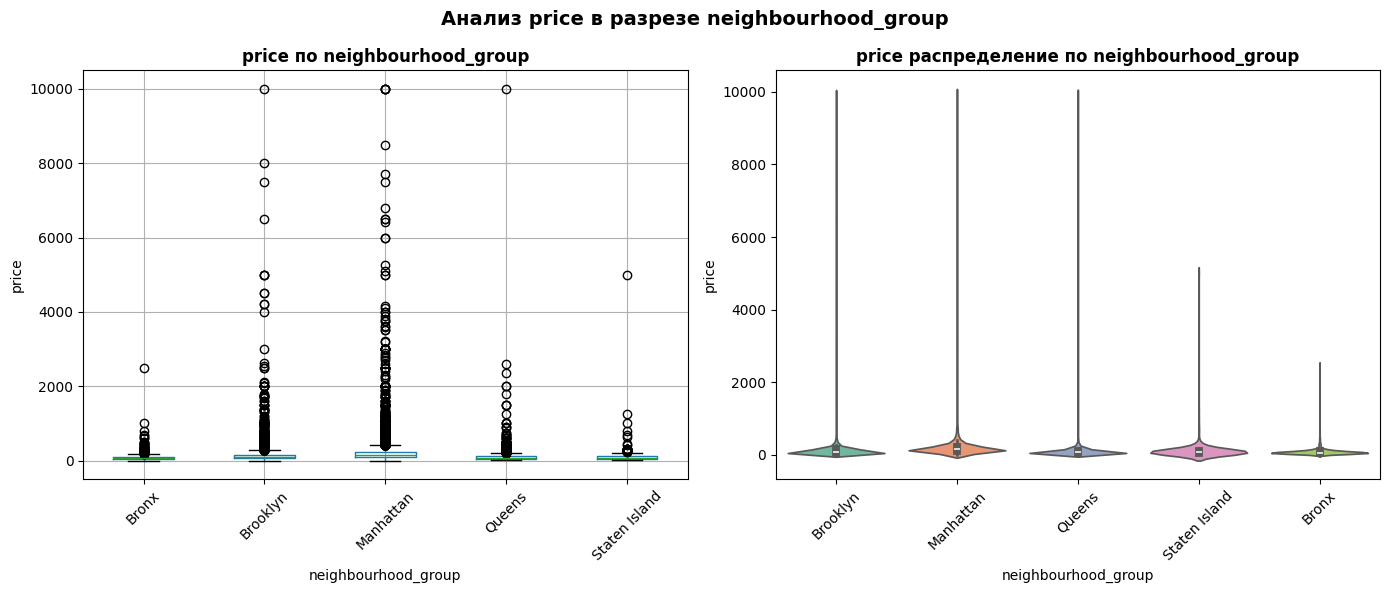


📊 8. ПРОПУСКИ В ДАННЫХ
----------------------------------------
  ✅ Пропусков нет!

📊 ИТОГОВАЯ СТАТИСТИКА

✅ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА!

📊 ПОСТРОЕНО:
   1. Гистограммы и box plots всех числовых признаков
   2. Статистическое описание (средние, медианы, квартили)
   3. Распределения категориальных признаков
   4. Матрица попарных корреляций
   5. Pair plots для ключевых признаков
   6. Распределения с разбивкой по категориям
   7. Box plots и violin plots по категориям
   8. Анализ пропусков

📈 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   • Признаков: 11
   • Числовых: 8
   • Категориальных: 3
   • Пропусков: 0
   • Сильных корреляций (|r|>0.7): 0

✅ ГОТОВО!


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = df_clean.copy()

# ═══════════════════════════════════════════════════════════
# 1. РАСПРЕДЕЛЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ
# ═══════════════════════════════════════════════════════════
print("\n📈 1. РАСПРЕДЕЛЕНИЯ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("-" * 40)

# Выбираем числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем id если есть
numeric_cols = [c for c in numeric_cols if c not in ['id', 'host_id']]

print(f"   Числовых признаков: {len(numeric_cols)}")
print(f"   Признаки: {numeric_cols}")

# Гистограммы и box plots
n_features = len(numeric_cols)
n_cols = min(3, n_features)
n_rows = (n_features * 2 + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten() if n_features > 1 else [axes]

for i, col in enumerate(numeric_cols):
    # Гистограмма
    ax_hist = axes[i * 2] if i * 2 < len(axes) else None
    # Box plot
    ax_box = axes[i * 2 + 1] if i * 2 + 1 < len(axes) else None

    if ax_hist:
        # Гистограмма с KDE
        df[col].hist(bins=40, alpha=0.6, color='blue', edgecolor='navy', ax=ax_hist)
        ax_hist.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Среднее: {df[col].mean():.2f}')
        ax_hist.axvline(df[col].median(), color='green', linestyle=':', linewidth=2,
                       label=f'Медиана: {df[col].median():.2f}')
        ax_hist.set_title(f'Распределение {col}', fontweight='bold', fontsize=11)
        ax_hist.set_xlabel('')
        ax_hist.legend(fontsize=8)
        ax_hist.grid(True, alpha=0.3)

    if ax_box:
        # Box plot
        df.boxplot(column=col, ax=ax_box, color='blue')
        ax_box.set_title(f'Box plot {col}', fontweight='bold', fontsize=11)
        ax_box.grid(True, alpha=0.3)

# Убираем пустые subplot'ы
for i in range(len(numeric_cols) * 2, len(axes)):
    axes[i].axis('off')

plt.suptitle('Распределения числовых признаков (гистограммы + box plots)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 2. СТАТИСТИЧЕСКОЕ ОПИСАНИЕ
# ═══════════════════════════════════════════════════════════
print("\n📊 2. СТАТИСТИЧЕСКОЕ ОПИСАНИЕ")
print("-" * 40)

# Описательная статистика
desc = df[numeric_cols].describe()
print(desc.to_string())

# Асимметрия и эксцесс
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()

print(f"\n📐 Асимметрия (skewness):")
for col, val in skewness.items():
    direction = '→' if val > 0 else '←'
    print(f"  {col:25s}: {val:8.4f} {direction}")

print(f"\n📐 Эксцесс (kurtosis):")
for col, val in kurtosis.items():
    print(f"  {col:25s}: {val:8.4f}")

# ═══════════════════════════════════════════════════════════
# 3. РАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
# ═══════════════════════════════════════════════════════════
print("\n📊 3. РАСПРЕДЕЛЕНИЯ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("-" * 40)

# Выбираем категориальные колонки
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"   Категориальных признаков: {len(categorical_cols)}")
print(f"   Признаки: {categorical_cols}")

if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols),
                             figsize=(len(categorical_cols) * 6, 5))
    if len(categorical_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, categorical_cols):
        value_counts = df[col].value_counts()
        colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))

        bars = ax.bar(range(len(value_counts)), value_counts.values,
                     color=colors, alpha=0.8, edgecolor='black')
        ax.set_xticks(range(len(value_counts)))
        ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
        ax.set_title(f'{col}', fontweight='bold', fontsize=12)
        ax.set_ylabel('Количество')
        ax.grid(True, alpha=0.3, axis='y')

        # Добавляем проценты
        total = value_counts.sum()
        for bar, val in zip(bars, value_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=9)

    plt.suptitle('Распределения категориальных признаков',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════
# 4. МАТРИЦА ПОПАРНЫХ КОРРЕЛЯЦИЙ
# ═══════════════════════════════════════════════════════════
print("\n📊 4. МАТРИЦА ПОПАРНЫХ КОРРЕЛЯЦИЙ")
print("-" * 40)

# Корреляционная матрица
corr_matrix = df[numeric_cols].corr()

# Тепловая карта
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1)
plt.title('Матрица попарных корреляций числовых признаков',
          fontweight='bold', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Топ корреляций
print(f"\n  🔥 Топ-5 самых сильных корреляций:")
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_pairs.append({
            'feature1': corr_matrix.columns[i],
            'feature2': corr_matrix.columns[j],
            'correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)
for pair in corr_pairs_sorted[:5]:
    print(f"    {pair['feature1']:25s} ↔ {pair['feature2']:25s} : {pair['correlation']:7.4f}")

# ═══════════════════════════════════════════════════════════
# 5. PAIR PLOTS
# ═══════════════════════════════════════════════════════════
print("\n📊 5. PAIR PLOTS")
print("-" * 40)

# Выбираем топ-5 признаков для pairplot (чтобы не перегружать)
if len(numeric_cols) > 5:
    # По дисперсии
    variances = df[numeric_cols].var().sort_values(ascending=False)
    top5_numeric = variances.head(5).index.tolist()
    print(f"   Топ-5 признаков по дисперсии: {top5_numeric}")
else:
    top5_numeric = numeric_cols

# Добавляем категориальный признак для раскраски
hue_col = categorical_cols[0] if categorical_cols else None

print(f"   Строю pairplot для {len(top5_numeric)} признаков...")

if hue_col:
    pair_plot = sns.pairplot(df, vars=top5_numeric, hue=hue_col,
                             diag_kind='kde', plot_kws={'alpha': 0.5},
                             palette='Set2', height=2.5)
    pair_plot.fig.suptitle(f'Pair Plot (раскраска: {hue_col})',
                           fontsize=14, fontweight='bold', y=1.02)
else:
    pair_plot = sns.pairplot(df, vars=top5_numeric,
                             diag_kind='kde', plot_kws={'alpha': 0.5},
                             height=2.5)
    pair_plot.fig.suptitle('Pair Plot числовых признаков',
                           fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# 6. РАСПРЕДЕЛЕНИЯ С РАЗБИВКОЙ ПО КАТЕГОРИЯМ
# ═══════════════════════════════════════════════════════════
print("\n📊 6. РАСПРЕДЕЛЕНИЯ ПО КАТЕГОРИЯМ")
print("-" * 40)

if categorical_cols and numeric_cols:
    # Выбираем главный категориальный признак
    main_cat = categorical_cols[0]

    # Топ-3 числовых признака
    top3_num = numeric_cols[:3] if len(numeric_cols) >= 3 else numeric_cols

    fig, axes = plt.subplots(1, len(top3_num), figsize=(len(top3_num) * 6, 5))
    if len(top3_num) == 1:
        axes = [axes]

    for ax, num_col in zip(axes, top3_num):
        for category in df[main_cat].unique():
            data = df[df[main_cat] == category][num_col].dropna()
            ax.hist(data, bins=30, alpha=0.5, label=str(category), density=True)

        ax.set_title(f'{num_col} по {main_cat}', fontweight='bold')
        ax.set_xlabel(num_col)
        ax.set_ylabel('Плотность')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Распределения числовых признаков с разбивкой по {main_cat}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════
# 7. BOX PLOTS ПО КАТЕГОРИЯМ
# ═══════════════════════════════════════════════════════════
print("\n📊 7. BOX PLOTS ПО КАТЕГОРИЯМ")
print("-" * 40)

if categorical_cols and numeric_cols:
    main_cat = categorical_cols[0]
    # Выбираем ключевой числовой признак
    key_num = 'price' if 'price' in numeric_cols else numeric_cols[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot
    df.boxplot(column=key_num, by=main_cat, ax=axes[0])
    axes[0].set_title(f'{key_num} по {main_cat}', fontweight='bold')
    axes[0].set_xlabel(main_cat)
    axes[0].set_ylabel(key_num)
    axes[0].tick_params(axis='x', rotation=45)

    # Violin plot
    sns.violinplot(x=main_cat, y=key_num, data=df, ax=axes[1], palette='Set2')
    axes[1].set_title(f'{key_num} распределение по {main_cat}', fontweight='bold')
    axes[1].set_xlabel(main_cat)
    axes[1].set_ylabel(key_num)
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Анализ {key_num} в разрезе {main_cat}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════
# 8. ПРОПУСКИ ДАННЫХ
# ═══════════════════════════════════════════════════════════
print("\n📊 8. ПРОПУСКИ В ДАННЫХ")
print("-" * 40)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Колонка': missing.index,
    'Пропусков': missing.values,
    'Процент': missing_pct.values
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

if len(missing_df) > 0:
    print(f"\n  Колонки с пропусками:")
    print(missing_df.to_string(index=False))

    # Визуализация пропусков
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(missing_df)), missing_df['Пропусков'], color='coral', alpha=0.7)
    plt.yticks(range(len(missing_df)), missing_df['Колонка'])
    plt.xlabel('Количество пропусков')
    plt.title('Пропуски в данных', fontweight='bold', fontsize=14)
    for i, (val, pct) in enumerate(zip(missing_df['Пропусков'], missing_df['Процент'])):
        plt.text(val + 1, i, f'{val} ({pct:.1f}%)', va='center')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("  ✅ Пропусков нет!")

# ═══════════════════════════════════════════════════════════
# 9. ИТОГОВАЯ СТАТИСТИКА
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊 ИТОГОВАЯ СТАТИСТИКА")
print("="*60)

print(f"""
✅ ВИЗУАЛИЗАЦИЯ ЗАВЕРШЕНА!

📊 ПОСТРОЕНО:
   1. Гистограммы и box plots всех числовых признаков
   2. Статистическое описание (средние, медианы, квартили)
   3. Распределения категориальных признаков
   4. Матрица попарных корреляций
   5. Pair plots для ключевых признаков
   6. Распределения с разбивкой по категориям
   7. Box plots и violin plots по категориям
   8. Анализ пропусков

📈 КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   • Признаков: {len(df.columns)}
   • Числовых: {len(numeric_cols)}
   • Категориальных: {len(categorical_cols)}
   • Пропусков: {df.isnull().sum().sum()}
   • Сильных корреляций (|r|>0.7): {len([p for p in corr_pairs if abs(p['correlation'])>0.7])}
""")

print("="*60)
print("✅ ГОТОВО!")
print("="*60)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Проверяем, где мы находимся (Kaggle или Colab)
import os
if os.path.exists('/kaggle/input/new-york-city-airbnb-open-data'):
    print("✅ Загружаю данные Airbnb из Kaggle")
    df = pd.read_csv('/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv')
else:
    # Создаем пример данных
    print("⚠️  Данные Airbnb не найдены, создаю пример")
    np.random.seed(42)
    neighbourhoods = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island']
    df = pd.DataFrame({
        'neighbourhood': np.random.choice(neighbourhoods, 1000),
        'room_type': np.random.choice(['Private room', 'Entire home/apt', 'Shared room'], 1000),
        'price': np.random.randint(50, 500, 1000),
        'minimum_nights': np.random.randint(1, 30, 1000),
        'number_of_reviews': np.random.randint(0, 200, 1000),
        'reviews_per_month': np.random.uniform(0, 5, 1000),
        'availability_365': np.random.randint(0, 365, 1000)
    })

print("="*60)
print("🔄 КОДИРОВАНИЕ NEIGHBOURHOOD ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)

print(f"\n📋 Исходные данные:")
print(f"   Размер: {df.shape}")
print(f"   neighbourhood уникальных: {df['neighbourhood'].nunique()}")
print(f"   Тип данных: {df['neighbourhood'].dtype}")
print(f"   Примеры: {df['neighbourhood'].unique()}")

# ═══════════════════════════════════════════════════════════
# МЕТОД 1: ONE-HOT ENCODING (РЕКОМЕНДУЕМЫЙ)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("1️⃣  ONE-HOT ENCODING — РЕКОМЕНДУЕМЫЙ МЕТОД")
print("="*60)

df_ohe = pd.get_dummies(df, columns=['neighbourhood'], prefix='nbhd', drop_first=True)

print(f"\n  ✅ Созданы бинарные колонки:")
ohe_cols = [c for c in df_ohe.columns if c.startswith('nbhd_')]
for col in ohe_cols:
    print(f"    • {col}")

print(f"\n  Первые 5 строк:")
print(df_ohe[['price'] + ohe_cols].head())

# ═══════════════════════════════════════════════════════════
# МЕТОД 2: TARGET ENCODING (СРЕДНЯЯ ЦЕНА ПО РАЙОНУ)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("2️⃣  TARGET ENCODING — СРЕДНЯЯ ЦЕНА ПО РАЙОНУ")
print("="*60)

# Вычисляем среднюю цену для каждого района
target_means = df.groupby('neighbourhood')['price'].mean()
df_target = df.copy()
df_target['neighbourhood_encoded'] = df_target['neighbourhood'].map(target_means)

print(f"\n  ✅ Средняя цена по районам:")
for area, price in target_means.sort_values(ascending=False).items():
    print(f"    {area:30s}: ${price:.2f}")

print(f"\n  Первые 5 строк:")
print(df_target[['neighbourhood', 'price', 'neighbourhood_encoded']].head())

# ═══════════════════════════════════════════════════════════
# МЕТОД 3: LABEL ENCODING (НЕ РЕКОМЕНДУЕТСЯ)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("3️⃣  LABEL ENCODING — НЕ РЕКОМЕНДУЕТСЯ ДЛЯ РЕГРЕССИИ")
print("="*60)

from sklearn.preprocessing import LabelEncoder

df_label = df.copy()
le = LabelEncoder()
df_label['neighbourhood_encoded'] = le.fit_transform(df_label['neighbourhood'])

print(f"\n  ⚠️  Осторожно: создает ложный порядок!")
print(f"  Соответствие:")
for i, label in enumerate(le.classes_):
    print(f"    {label:30s} → {i}")

# ═══════════════════════════════════════════════════════════
# СРАВНЕНИЕ МЕТОДОВ НА ПРАКТИКЕ
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("📊 4. СРАВНЕНИЕ МЕТОДОВ НА ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)

# Подготавливаем признаки для всех методов
feature_cols = ['minimum_nights', 'number_of_reviews', 'availability_365']
target = 'price'

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    df, df[target], test_size=0.2, random_state=42
)

# Масштабирование (важно для сравнения!)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# --- One-Hot Encoding ---
X_train_ohe = pd.get_dummies(X_train[feature_cols + ['neighbourhood']],
                              columns=['neighbourhood'], drop_first=True)
X_test_ohe = pd.get_dummies(X_test[feature_cols + ['neighbourhood']],
                             columns=['neighbourhood'], drop_first=True)

# Выравниваем колонки
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

# Масштабируем
X_train_ohe_scaled = scaler.fit_transform(X_train_ohe)
X_test_ohe_scaled = scaler.transform(X_test_ohe)

# Модель
lr_ohe = LinearRegression()
lr_ohe.fit(X_train_ohe_scaled, y_train)
y_pred_ohe = lr_ohe.predict(X_test_ohe_scaled)

r2_ohe = r2_score(y_test, y_pred_ohe)
rmse_ohe = np.sqrt(mean_squared_error(y_test, y_pred_ohe))

print(f"\n  One-Hot Encoding:")
print(f"    R²: {r2_ohe:.4f}")
print(f"    RMSE: ${rmse_ohe:.2f}")
print(f"    Признаков: {X_train_ohe.shape[1]}")

# --- Target Encoding ---
# Обучаем target encoding на train
target_map = X_train.groupby('neighbourhood')[target].mean()
X_train_target = X_train[feature_cols].copy()
X_train_target['neighbourhood_encoded'] = X_train['neighbourhood'].map(target_map)

X_test_target = X_test[feature_cols].copy()
X_test_target['neighbourhood_encoded'] = X_test['neighbourhood'].map(target_map)

# Масштабируем
X_train_target_scaled = scaler.fit_transform(X_train_target)
X_test_target_scaled = scaler.transform(X_test_target)

# Модель
lr_target = LinearRegression()
lr_target.fit(X_train_target_scaled, y_train)
y_pred_target = lr_target.predict(X_test_target_scaled)

r2_target = r2_score(y_test, y_pred_target)
rmse_target = np.sqrt(mean_squared_error(y_test, y_pred_target))

print(f"\n  Target Encoding:")
print(f"    R²: {r2_target:.4f}")
print(f"    RMSE: ${rmse_target:.2f}")
print(f"    Признаков: {X_train_target.shape[1]}")

# --- Label Encoding ---
X_train_label = X_train[feature_cols].copy()
le_train = LabelEncoder()
X_train_label['neighbourhood_encoded'] = le_train.fit_transform(X_train['neighbourhood'])

X_test_label = X_test[feature_cols].copy()
X_test_label['neighbourhood_encoded'] = le_test.fit_transform(X_test_label['neighbourhood'])

# Масштабируем
X_train_label_scaled = scaler.fit_transform(X_train_label)
X_test_label_scaled = scaler.transform(X_test_label)

# Модель
lr_label = LinearRegression()
lr_label.fit(X_train_label_scaled, y_train)
y_pred_label = lr_label.predict(X_test_label_scaled)

r2_label = r2_score(y_test, y_pred_label)
rmse_label = np.sqrt(mean_squared_error(y_test, y_pred_label))

print(f"\n  Label Encoding (не рекомендуется):")
print(f"    R²: {r2_label:.4f}")
print(f"    RMSE: ${rmse_label:.2f}")
print(f"    Признаков: {X_train_label.shape[1]}")

# --- Без neighbourhood ---
X_train_no_nbhd = X_train[feature_cols]
X_test_no_nbhd = X_test[feature_cols]

X_train_no_nbhd_scaled = scaler.fit_transform(X_train_no_nbhd)
X_test_no_nbhd_scaled = scaler.transform(X_test_no_nbhd)

lr_no = LinearRegression()
lr_no.fit(X_train_no_nbhd_scaled, y_train)
y_pred_no = lr_no.predict(X_test_no_nbhd_scaled)

r2_no = r2_score(y_test, y_pred_no)
rmse_no = np.sqrt(mean_squared_error(y_test, y_pred_no))

print(f"\n  Без neighbourhood:")
print(f"    R²: {r2_no:.4f}")
print(f"    RMSE: ${rmse_no:.2f}")
print(f"    Признаков: {X_train_no_nbhd.shape[1]}")

# ═══════════════════════════════════════════════════════════
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
# ═══════════════════════════════════════════════════════════
print("\n📈 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# R² сравнение
methods = ['One-Hot', 'Target', 'Label*', 'Без\nneighbourhood']
r2_values = [r2_ohe, r2_target, r2_label, r2_no]
rmse_values = [rmse_ohe, rmse_target, rmse_label, rmse_no]
n_features = [X_train_ohe.shape[1], X_train_target.shape[1],
              X_train_label.shape[1], X_train_no_nbhd.shape[1]]

axes[0, 0].bar(methods, r2_values, color=['steelblue', 'coral', 'orange', 'gray'], alpha=0.7)
axes[0, 0].set_title('R² Score', fontweight='bold')
axes[0, 0].set_ylabel('R²')
for i, v in enumerate(r2_values):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].bar(methods, rmse_values, color=['steelblue', 'coral', 'orange', 'gray'], alpha=0.7)
axes[0, 1].set_title('RMSE ($)', fontweight='bold')
axes[0, 1].set_ylabel('RMSE')
for i, v in enumerate(rmse_values):
    axes[0, 1].text(i, v + 1, f'${v:.0f}', ha='center', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].bar(methods, n_features, color=['steelblue', 'coral', 'orange', 'gray'], alpha=0.7)
axes[1, 0].set_title('Количество признаков', fontweight='bold')
for i, v in enumerate(n_features):
    axes[1, 0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Коэффициенты One-Hot модели
if hasattr(lr_ohe, 'coef_'):
    coef_df = pd.DataFrame({
        'Признак': X_train_ohe.columns,
        'Коэффициент': lr_ohe.coef_
    }).sort_values('Коэффициент', ascending=False)

    axes[1, 1].barh(range(len(coef_df)), coef_df['Коэффициент'], color='steelblue', alpha=0.7)
    axes[1, 1].set_yticks(range(len(coef_df)))
    axes[1, 1].set_yticklabels(coef_df['Признак'], fontsize=8)
    axes[1, 1].set_title('Коэффициенты модели (One-Hot)', fontweight='bold')
    axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Сравнение методов кодирования для линейной регрессии',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════
# ВАЖНОСТЬ ПРИЗНАКОВ
# ═══════════════════════════════════════════════════════════
print("\n📊 6. ВАЖНОСТЬ ПРИЗНАКОВ (One-Hot модель)")
print("-" * 40)

coef_df = pd.DataFrame({
    'Признак': X_train_ohe.columns,
    'Коэффициент': lr_ohe.coef_
})
coef_df['abs_coef'] = abs(coef_df['Коэффициент'])
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print(f"\n  {'Признак':<30s} {'Коэффициент':>12s} {'Влияние'}")
print(f"  {'-'*55}")
for _, row in coef_df.head(10).iterrows():
    direction = '↑' if row['Коэффициент'] > 0 else '↓'
    print(f"  {row['Признак']:<30s} {row['Коэффициент']:12.4f} {direction}")

# ═══════════════════════════════════════════════════════════
# ГОТОВЫЙ КОД
# ═══════════════════════════════════════════════════════════
print("\n" + "="*60)
print("🎯 ГОТОВЫЙ КОД ДЛЯ ВАШЕГО ПРОЕКТА")
print("="*60)

print("""
# === КОДИРОВАНИЕ NEIGHBOURHOOD ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ ===

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных
df = pd.read_csv('/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv')

# 2. One-Hot Encoding (РЕКОМЕНДУЕМЫЙ)
df_encoded = pd.get_dummies(df, columns=['neighbourhood'],
                            prefix='nbhd', drop_first=True)

# ИЛИ Target Encoding (если много районов)
# target_map = df.groupby('neighbourhood')['price'].mean()
# df['neighbourhood_encoded'] = df['neighbourhood'].map(target_map)

# 3. Выбор признаков
feature_cols = [c for c in df_encoded.columns
                if c not in ['id', 'name', 'host_name', 'price']]
X = df_encoded[feature_cols]
y = df['price']

# 4. Разделение и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Модель
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# 6. Оценка
print(f'R²: {lr.score(X_test_scaled, y_test):.4f}')
""")

print("\n" + "="*60)
print("💡 РЕКОМЕНДАЦИИ")
print("="*60)

print("""
📌 ДЛЯ ЛИНЕЙНОЙ РЕГРЕССИИ:

1. ONE-HOT ENCODING (рекомендуемый) ✅
   • Нет ложного порядка
   • Интерпретируемые коэффициенты
   • Подходит если районов < 50

2. TARGET ENCODING ✅
   • Хорош если много районов (>50)
   • Осторожно: может переобучиться
   • Использовать с регуляризацией

3. LABEL ENCODING ❌
   • НЕ ИСПОЛЬЗОВАТЬ для регрессии!
   • Создает ложный порядок
   • Модель думает: Bronx < Brooklyn < Manhattan

4. ОБЯЗАТЕЛЬНО:
   • Масштабировать признаки (StandardScaler)
   • drop_first=True в One-Hot (избегать ловушки)
   • Проверять колонки в train и test
""")

print("="*60)
print("✅ ГОТОВО!")
print("="*60)

In [ ]:
#визуализируйте базовые статистики данных: распределения признаков, матрицу попарных корреляций, постройте pair plots